### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [94]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv.gz` file.




In [95]:
data = pd.read_csv('data/coupons.csv.gz')

In [96]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

First things first, we have to correct the typo to preserve sanity.

In [97]:
data.rename(columns={'passanger':'passenger'}, inplace=True)

Considering duplicate rows here. There are indeed duplicate rows and in this case these can easily represent multiple, valid responses that happen to have the same content. A person could accept/reject a coupon with the same context at the same time on a different day, for instance. There is no `user_id` and `survey_submission_timestamp` or anything like that that could indicate true, redundant and duplicate responses that may skew the data.

In [98]:
unique_data = data.drop_duplicates()
print(f'Original data.shape\n{data.shape}:')
print(f'Deduped unique_data.shape\n{unique_data.shape}:')

Original data.shape
(12684, 26):
Deduped unique_data.shape
(12610, 26):


Here we'll take a quick look at which columns have missing values and note that for later.

In [99]:
data.isna().sum().pipe(lambda x: x[x > 0])

,0
car,12576
Bar,107
CoffeeHouse,217
CarryAway,151
RestaurantLessThan20,130
Restaurant20To50,189


Let's note which columns seem to be intended to take string data, as those ones may or may not be constrained to sensible values.

In [100]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passenger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [101]:
# This was used to explore the values in all of the string columns. Uncomment
# and run to see. It does create an annoyingly-long scrollable area within a
# scrollable area so this is commented out unless needed.

# with pd.option_context('display.max_rows', None):
#    for label, content in data.select_dtypes(include=['object']).items():
#      print(f'\n\n\nColumn: {label}')
#      display(content.value_counts(normalize=True, dropna=False))

3. Decide what to do about your missing data -- drop, replace, other...

From above, we note that columns `car`, `Bar`, `CoffeeHouse`, `CarryAway`, `RestaurantLessThan20` and `Restaurant20To50` had null values. All of these columns seem to house categorical data based on the value counts pulled above.

Starting with `car`, we saw that this value is rarely filled in, with over 99% of values being `null`. This column is highly unlikely to be useful in determining whether or not a coupon will be accepted. Additionally, the column contains values which are not cars, examples being `Scooter and motorcycle` and `do not drive`. This one's a good candidate for dropping altogether.

For the rest, mode imputation is a common and simple approach to fill in missing values for categorical data. For `Bar`, `CoffeeHouse`, `CarryAway`, `RestaurantLessThan20` and `Restaurant20To50`, the proportion of null values are 0.84%, 1.71%, 1.19%, 1.03% and 1.49% respectively. Observing the most frequent and the second-most-frequent categories for each column, only `CoffeeHouse` could potentially have it's mode altered by the selection of the incorrect imputation method. This is noted and we can live with that for now.

In [102]:
# Putting together a table to show: the number of nulls for each column, the
# mode (major mode), the second-most frequent value (minor mode) and the
# percentage difference between the major and minor modes. The intent is to
# see if an incorrect choice of imputation method here could impact which value
# becomes the mode for a given column.

imputation_columns = ['Bar', 'CoffeeHouse', 'CarryAway',
                      'RestaurantLessThan20', 'Restaurant20To50']
imputation_df = pd.DataFrame(columns=[
    'Column Name',
    'Null %',
    'Major Mode %',
    'Minor Mode %',
    'Major-Minor % Delta']
)
for column in imputation_columns:
  value_counts = data[column].value_counts(dropna=False)
  row_count = data[column].size
  null_pct = data[column].isna().sum() / row_count * 100
  major_mode_pct = value_counts.values[0] / row_count * 100
  minor_mode_pct = value_counts.values[1] / row_count * 100
  delta = major_mode_pct - minor_mode_pct
  imputation_df.loc[len(imputation_df)] = [column, null_pct, major_mode_pct,
                                           minor_mode_pct, delta]
display(imputation_df)

,Column Name,Null %,Major Mode %,Minor Mode %,Major-Minor % Delta
0,Bar,0.843582,40.972879,27.451908,13.520971
1,CoffeeHouse,1.710817,26.687165,25.425733,1.261432
2,CarryAway,1.190476,36.833806,33.569852,3.263955
3,RestaurantLessThan20,1.024913,42.384106,28.224535,14.159571
4,Restaurant20To50,1.490066,47.910754,25.938190,21.972564


In [103]:
data.drop(columns=['car'], inplace=True)
for column in imputation_columns:
  data[column] = data[column].fillna(data[column].value_counts().index[0])

Recheck our null counts

In [104]:
# No output rows expected
data.isna().sum().pipe(lambda x: x[x > 0])

,0


4. What proportion of the total observations chose to accept the coupon?



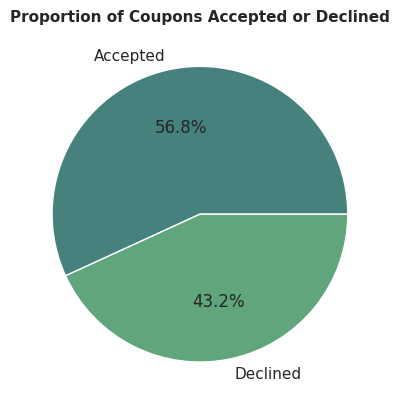

In [105]:
(
  data['Y'].value_counts()
    .rename(index={0:'Declined', 1:'Accepted'})
    .plot.pie(autopct='%1.1f%%', ylabel='', colors=['#47817e', '#60a57c'])
)
plt.title('Proportion of Coupons Accepted or Declined', fontsize=11, fontweight='bold')
plt.show()

Approximately 57% of the observations chose to accept the coupon.

5. Use a bar plot to visualize the `coupon` column.

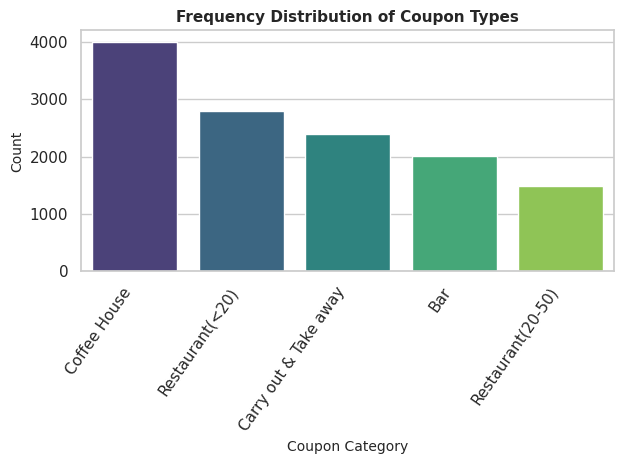

In [106]:
coupon_counts = data['coupon'].value_counts()
sns.set_theme(style='whitegrid')
sns.barplot(
    x=coupon_counts.index,
    y=coupon_counts.values,
    palette='viridis',
    hue=coupon_counts.index
)
plt.title('Frequency Distribution of Coupon Types', fontsize=11, fontweight='bold')
plt.xlabel('Coupon Category', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

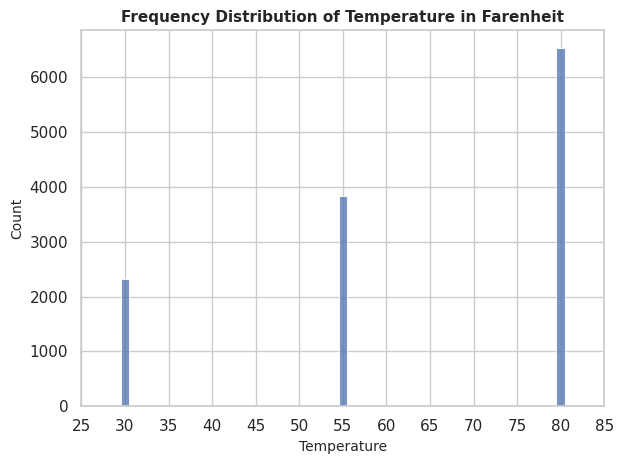

temperature
80    6528
55    3840
30    2316
Name: count, dtype: int64


In [107]:
ax = sns.histplot(
       data=data,
       x='temperature',
       discrete=True   # since there are few unique values
)
ax.set_xticks(np.arange(25, 90, 5))
plt.title('Frequency Distribution of Temperature in Farenheit',
          fontsize=11, fontweight='bold')
plt.xlabel('Temperature', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.tight_layout()
plt.show()
print(data['temperature'].value_counts()) # double checking

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [108]:
bar_coupons = data.query('coupon == "Bar"')

2. What proportion of bar coupons were accepted?


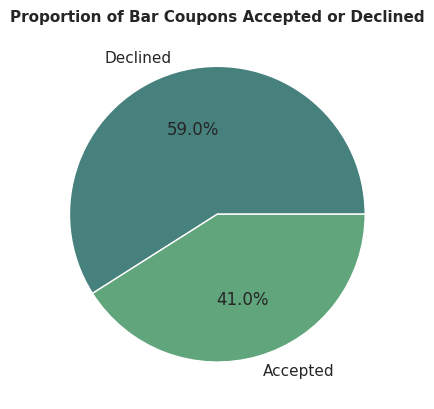

In [109]:
(
  bar_coupons['Y'].value_counts()
    .rename(index={0:'Declined', 1:'Accepted'})
    .plot.pie(autopct='%1.1f%%', ylabel='', colors=['#47817e', '#60a57c'])
)
plt.title('Proportion of Bar Coupons Accepted or Declined',
          fontsize=11, fontweight='bold')
plt.show()

41% of bar coupons were accepted.

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


For this one we're looking at the `Bar` column and lumping `never`, `less1` and `1~3` as one category and comparing the acceptance rate of that sample versus a category consisting of responses with values `4~8` and `gt8`.

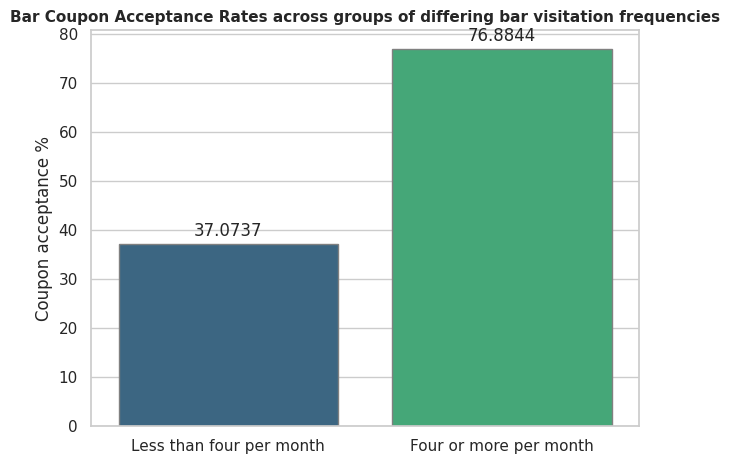

In [110]:
less_than_four = (
    bar_coupons.query('Bar in ["never", "less1", "1~3"]')['Y']
    .value_counts(normalize=True)
    .rename(index={0:'Declined', 1:'Accepted'})
    .rename('Less than four per month')
)

four_or_more = (
    bar_coupons.query('Bar in ["4~8", "gt8"]')['Y']
    .value_counts(normalize=True)
    .rename(index={0:'Declined', 1:'Accepted'})
    .rename('Four or more per month')
)

bar_coupon_1_df = (
    pd.DataFrame({'group': [less_than_four.name, four_or_more.name],
                  'acceptance': [less_than_four.loc['Accepted'] * 100,
                                 four_or_more.loc['Accepted'] * 100]
                  })
)

ax = sns.barplot(
       data=bar_coupon_1_df,
       x='group',
       y='acceptance',
       palette='viridis',
       hue=bar_coupon_1_df.index,
       legend=False,
       edgecolor='grey',
       linewidth=1
)

title = (
    'Bar Coupon Acceptance Rates across groups of '
    'differing bar visitation frequencies'
)
plt.title(title, fontsize=11, fontweight='bold')
plt.xlabel('')
plt.ylabel('Coupon acceptance %')
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, padding=3) # add value labels above bars
plt.show()


The acceptance rate for bar coupons is a *lot* higher — more than double — for those who frequent bars four or more times per month. Intuitively this makes sense.

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


For this one we're going to have trouble getting an accurate picture given the requirement to look at drivers that go to a bar *more* than once a month. In the `Bar` categorical data, we don't have values that start from 2 and the only values strictly above 1 are the categories `4~8` and `gt8`. `1~3` isn't helpful since it also contains 1.

So, realising we can't get an accurate answer, we can look at one case including the category `1~3` and one case exluding it. The real answer may be somewhere in-between.

Looking at the `Bar` column we'll start by lumping those with values `1~3`, `4~8` and `gt8` and who also have a value in `age` greater than or equal to 25 as one category and everything outside of the intersection of those things as the other category. Given the values in `age` this is easier to express as a value that is *not* `below21` or `21`.

The second scenario will be the same as above, just excluding the `1~3` category from the responses in `Bar`.

Another factor that weakens the answer is potentially ambiguity in defining 'over the age of 25', which could mean age 26 or greater, or simply mean 25 and any non-zero number of seconds/minutes/days. We'll assume 26 and above for this problem.

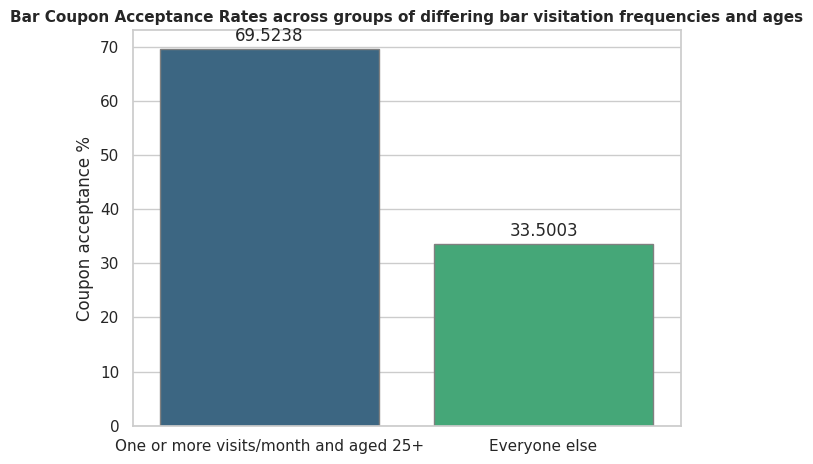

In [111]:
# Examining the first case that includes 1~3
one_plus_and_25_query = (
    '(Bar in ["1~3", "4~8", "gt8"]) & '
    '(age not in ["below21", "21"])'
)
one_plus_and_25 = (
    bar_coupons.query(one_plus_and_25_query)['Y']
    .value_counts(normalize=True)
    .rename(index={0:'Declined', 1:'Accepted'})
    .rename('One or more visits/month and aged 25+')
)

one_plus_and_25_inverse = (
    bar_coupons.query('not (' + one_plus_and_25_query + ')')['Y']
    .value_counts(normalize=True)
    .rename(index={0:'Declined', 1:'Accepted'})
    .rename('Everyone else')
)

bar_coupon_2_df = (
    pd.DataFrame({'group': [one_plus_and_25.name, one_plus_and_25_inverse.name],
                  'acceptance': [one_plus_and_25.loc['Accepted'] * 100,
                                 one_plus_and_25_inverse.loc['Accepted'] * 100]
                  })
)

ax = sns.barplot(
       data=bar_coupon_2_df,
       x='group',
       y='acceptance',
       palette='viridis',
       hue=bar_coupon_2_df.index,
       legend=False,
       edgecolor='grey',
       linewidth=1
)

title = (
    'Bar Coupon Acceptance Rates across groups of '
    'differing bar visitation frequencies and ages'
)
plt.title(title, fontsize=11, fontweight='bold')
plt.xlabel('')
plt.ylabel('Coupon acceptance %')
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, padding=3) # add value labels above bars
plt.show()


There is a significant difference in acceptance rate between the two subpopulations — roughly double the acceptance rate for those bargoers aged 25 or older. Looking at the data, this intuitively makes sense. Those under 25 are only represented by the categories `21` and `below21` and only one of those is of legal drinking age in the US (assuming this is in the US based on the temperature values which seem to be in farenheit but could also suggest the survey country is the Bahamas, Belize, the Cayman Islands, or Palau). Those 25 and older usually have a higher disposable income to spend at bars.

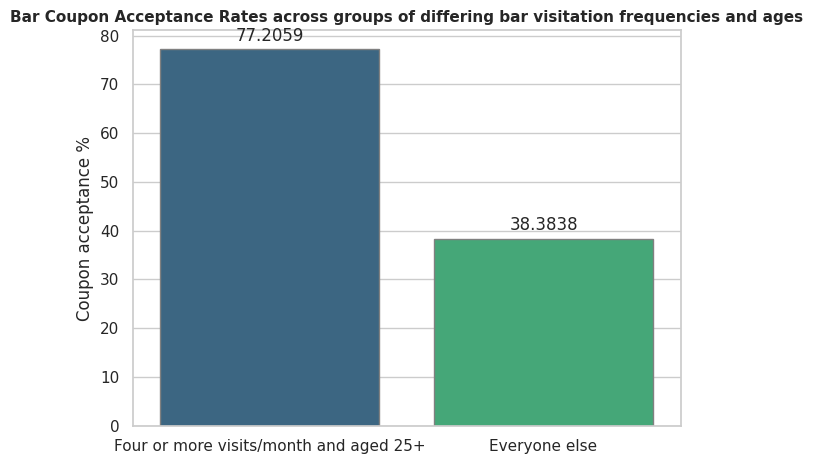

In [112]:
# Examining the second case that *excludes* 1~3
four_plus_and_25_query = (
  '(Bar in ["4~8", "gt8"]) & '
  '(age not in ["below21", "21"])'
)
four_plus_and_25 = (
    bar_coupons.query(four_plus_and_25_query)['Y']
    .value_counts(normalize=True)
    .rename(index={0:'Declined', 1:'Accepted'})
    .rename('Four or more visits/month and aged 25+')
)

four_plus_and_25_inverse = (
    bar_coupons.query('not (' + four_plus_and_25_query + ')')['Y']
    .value_counts(normalize=True)
    .rename(index={0:'Declined', 1:'Accepted'})
    .rename('Everyone else')
)

bar_coupon_3_df = (
    pd.DataFrame({'group': [four_plus_and_25.name, four_plus_and_25_inverse.name],
                  'acceptance': [four_plus_and_25.loc['Accepted'] * 100,
                                 four_plus_and_25_inverse.loc['Accepted'] * 100]
                  })
)

ax = sns.barplot(
       data=bar_coupon_3_df,
       x='group',
       y='acceptance',
       palette='viridis',
       hue=bar_coupon_3_df.index,
       legend=False,
       edgecolor='grey',
       linewidth=1
)

title = (
    'Bar Coupon Acceptance Rates across groups of '
    'differing bar visitation frequencies and ages'
)
plt.title(title, fontsize=11, fontweight='bold')
plt.xlabel('')
plt.ylabel('Coupon acceptance %')
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, padding=3) # add value labels above bars
plt.show()



This second case shows a higher acceptance rate for four bar visits a month and ages over 25 than in the previous case: 77.2% accepted vs. 69.5%. If the survey was redone to provide greater resolution in categories for the `Bar` column, we could answer the question directly.

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


We'll assume this means we'll compare the bar coupon acceptance rate between two groups: one group who is at the intersection of all the terms defined (bar frequency, passenger type and occupation); and another group which is everyone else. Again, the phrase '*more* than once a month' means we can't include the `Bar` category value of `1~3`.

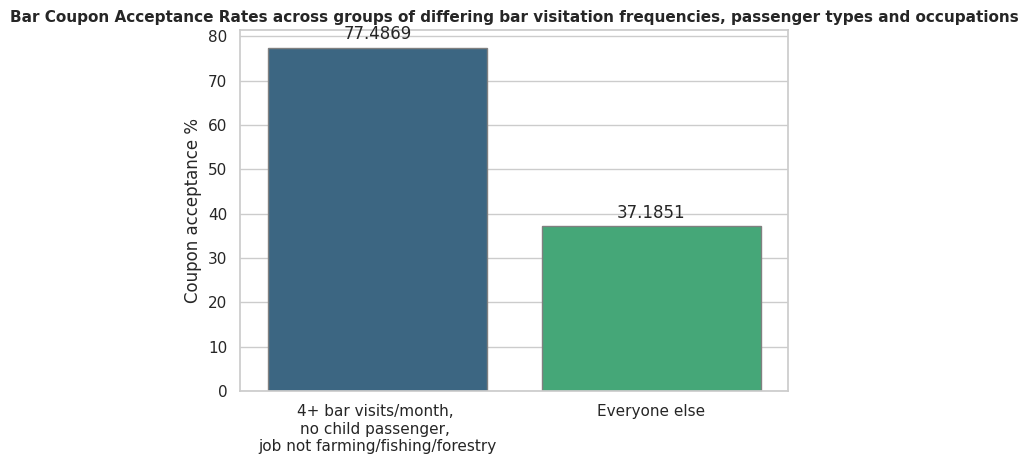

Target subpopulation size: 191
Inverse subpopulation size: 1826


In [113]:
# Examining the target population and excluding bar visitation at 1~3
bargoer_nokid_noag_query = (
  '(Bar in ["4~8", "gt8"]) & '
  '(passenger not in ["Kid(s)"]) & '
  '(occupation not in ["Farming Fishing & Forestry"])'
)
bargoer_nokid_noag = (
    bar_coupons.query(bargoer_nokid_noag_query)['Y']
    .value_counts(normalize=True)
    .rename(index={0:'Declined', 1:'Accepted'})
    .rename('4+ bar visits/month, \nno child passenger, \n'
            'job not farming/fishing/forestry')
)

bargoer_nokid_noag_inverse = (
    bar_coupons.query('not (' + bargoer_nokid_noag_query + ')')['Y']
    .value_counts(normalize=True)
    .rename(index={0:'Declined', 1:'Accepted'})
    .rename('Everyone else')
)

bar_coupon_4_df = (
    pd.DataFrame({'group': [bargoer_nokid_noag.name,
                            bargoer_nokid_noag_inverse.name],
                  'acceptance': [bargoer_nokid_noag.loc['Accepted'] * 100,
                                 bargoer_nokid_noag_inverse.loc['Accepted'] * 100]
                  })
)

ax = sns.barplot(
       data=bar_coupon_4_df,
       x='group',
       y='acceptance',
       palette='viridis',
       hue=bar_coupon_4_df.index,
       legend=False,
       edgecolor='grey',
       linewidth=1
)

title = (
    'Bar Coupon Acceptance Rates across groups of differing bar visitation '
    'frequencies, passenger types and occupations'
)
plt.title(title, fontsize=11, fontweight='bold')
plt.xlabel('')
plt.ylabel('Coupon acceptance %')
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, padding=3) # add value labels above bars
plt.show()

# Curious about the size of these populations, given the number of search terms
target_subpopulation_size = len(bar_coupons.query(bargoer_nokid_noag_query).index)
inverse_subpopulation_size = len(bar_coupons.query('not (' + bargoer_nokid_noag_query + ')').index)
print(f'Target subpopulation size: {target_subpopulation_size}')
print(f'Inverse subpopulation size: {inverse_subpopulation_size}')

The acceptance rate is more than double for frequent bargoers who aren't currently driving with kids and aren't working in the farming, fishing or forestry industries. Intuitively this makes sense again given the values and laws in the US disallowing allowing minors in bars. I note the subpopulation size of the target here is quite small relative to all of the other bar coupon recipients, at roughly 10%.

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



We'll choose the subpopulation *'go to cheap restaurants more than 4 times a month and income is less than 50K'*, although there is an issue with this. We'll assume that 'cheap restaurants' refers to those in the cheapest category, being represented by the column `RestaurantLessThan20`. Within that column we have values `1~3` and `4~8`, so representing *'more than four times a month'* can't be done with the data as collected as the `4~8` value also contains 4. We will assume includingh this category is okay for this answer and will just note this discrepancy as a weakness in the data as it applies to this analysis.

This subpopulation will be compared against the inverse subpopulation, so, everyone else.

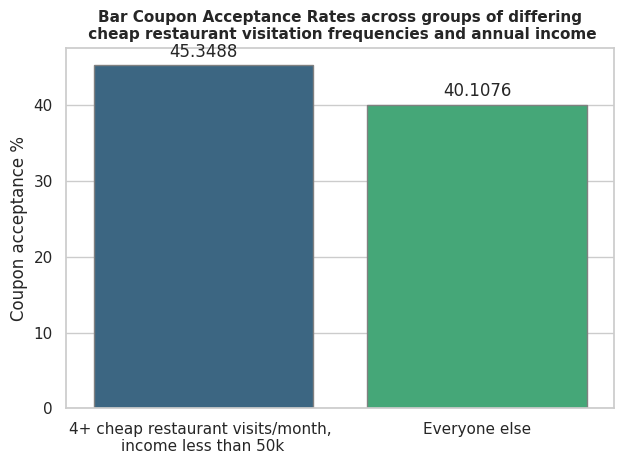

Target subpopulation size: 344
Inverse subpopulation size: 1673


In [114]:
# Examining the target subpopulation
cheap_restaurants_50k_query = (
  '(RestaurantLessThan20 in ["4~8", "gt8"]) & '
  '(income in ["Less than $12500", '
              '"$12500 - $24999", '
              '"$25000 - $37499", '
              '"$37500 - $49999"])'
)
cheap_restaurants_50k = (
    bar_coupons.query(cheap_restaurants_50k_query)['Y']
    .value_counts(normalize=True)
    .rename(index={0:'Declined', 1:'Accepted'})
    .rename('4+ cheap restaurant visits/month, \nincome less than 50k')
)

# Find the inverse subpopulation
cheap_restaurants_50k_inverse = (
    bar_coupons.query('not (' + cheap_restaurants_50k_query + ')')['Y']
    .value_counts(normalize=True)
    .rename(index={0:'Declined', 1:'Accepted'})
    .rename('Everyone else')
)

bar_coupon_5_df = (
    pd.DataFrame({'group': [cheap_restaurants_50k.name,
                            cheap_restaurants_50k_inverse.name],
                  'acceptance': [cheap_restaurants_50k.loc['Accepted'] * 100,
                                 cheap_restaurants_50k_inverse.loc['Accepted'] * 100]
                  })
)

ax = sns.barplot(
       data=bar_coupon_5_df,
       x='group',
       y='acceptance',
       palette='viridis',
       hue=bar_coupon_5_df.index,
       legend=False,
       edgecolor='grey',
       linewidth=1
)

title = (
    'Bar Coupon Acceptance Rates across groups of differing\n cheap restaurant '
    'visitation frequencies and annual income'
)
plt.title(title, fontsize=11, fontweight='bold')
plt.xlabel('')
plt.ylabel('Coupon acceptance %')
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, padding=3) # add value labels above bars
plt.show()

# Curious about the size of these populations, given the number of search terms
target_subpopulation_size = len(bar_coupons.query(cheap_restaurants_50k_query).index)
inverse_subpopulation_size = len(bar_coupons.query('not (' + cheap_restaurants_50k_query + ')').index)
print(f'Target subpopulation size: {target_subpopulation_size}')
print(f'Inverse subpopulation size: {inverse_subpopulation_size}')

So in this case, survey respondants who frequent the cheapest categroy of restaurants four or more times per month and who have a lower annual income accept bar coupons at roughly the same rate as everyone else. Based on this, we could say that a higher frequency of visits to cheap resturants and a lower annual income is not a great predictor of people who might accept a bar coupon.

Let's repeat this analysis to exlude the `4~8` category from `RestaurantLessThan20` so that we strictly get those who frequented cheap restaurants *more* than four times per month.

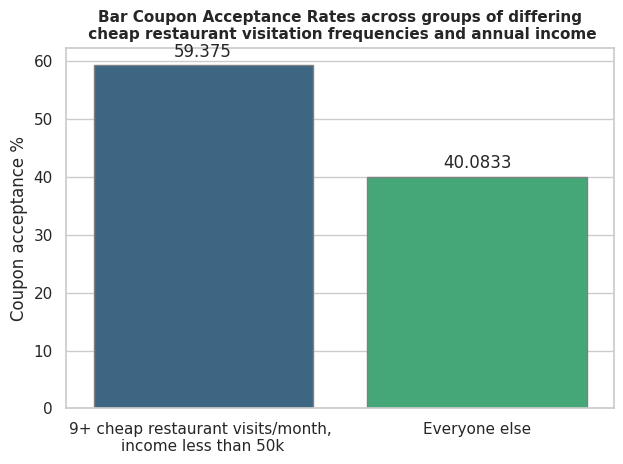

Target subpopulation size: 96
Inverse subpopulation size: 1921


In [115]:
# Examining the target subpopulation
cheap_restaurants_50k_query = (
  '(RestaurantLessThan20 in ["gt8"]) & ' # only more than 8 now
  '(income in ["Less than $12500", '
              '"$12500 - $24999", '
              '"$25000 - $37499", '
              '"$37500 - $49999"])'
)
cheap_restaurants_50k = (
    bar_coupons.query(cheap_restaurants_50k_query)['Y']
    .value_counts(normalize=True)
    .rename(index={0:'Declined', 1:'Accepted'})
    .rename('9+ cheap restaurant visits/month, \nincome less than 50k')
)

# Find the inverse subpopulation
cheap_restaurants_50k_inverse = (
    bar_coupons.query('not (' + cheap_restaurants_50k_query + ')')['Y']
    .value_counts(normalize=True)
    .rename(index={0:'Declined', 1:'Accepted'})
    .rename('Everyone else')
)

bar_coupon_5_df = (
    pd.DataFrame({'group': [cheap_restaurants_50k.name,
                            cheap_restaurants_50k_inverse.name],
                  'acceptance': [cheap_restaurants_50k.loc['Accepted'] * 100,
                                 cheap_restaurants_50k_inverse.loc['Accepted'] * 100]
                  })
)

ax = sns.barplot(
       data=bar_coupon_5_df,
       x='group',
       y='acceptance',
       palette='viridis',
       hue=bar_coupon_5_df.index,
       legend=False,
       edgecolor='grey',
       linewidth=1
)

title = (
    'Bar Coupon Acceptance Rates across groups of differing\n cheap restaurant '
    'visitation frequencies and annual income'
)
plt.title(title, fontsize=11, fontweight='bold')
plt.xlabel('')
plt.ylabel('Coupon acceptance %')
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, padding=3) # add value labels above bars
plt.show()

# Curious about the size of these populations, given the number of search terms
target_subpopulation_size = len(bar_coupons.query(cheap_restaurants_50k_query).index)
inverse_subpopulation_size = len(bar_coupons.query('not (' + cheap_restaurants_50k_query + ')').index)
print(f'Target subpopulation size: {target_subpopulation_size}')
print(f'Inverse subpopulation size: {inverse_subpopulation_size}')

Now we see a better signal for bar coupon acceptance. Those that eat at cheap restaurants *nine* or more times per month and have an annual income of less than $50k have a roughly 50% higher acceptance rate of bar coupons than the rest of the population.

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Based on the above observations, the subpopulation most likely to accept bar coupons are those who frequent bars four or more times per month *and* are over the age of 25, *or* are of any age and don't currently have a child passenger and don't work in fishing, forestry or farming. If this was an ad spend optimisation problem, the easiest group to target and receive the highest acceptance from would be those aged 25 or above and who frequent bars 4+ times a month.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

Let's take a look at the `Carry out & Take away` coupon group.

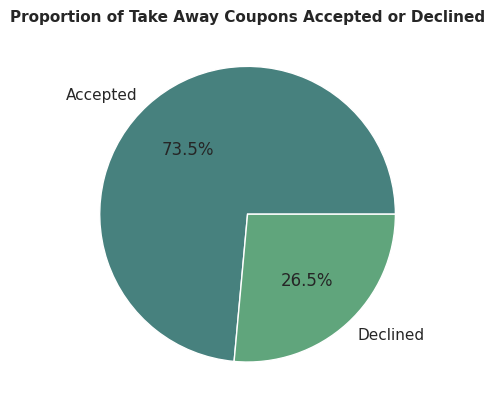

In [116]:
take_away = data.query('coupon == "Carry out & Take away"')

(
  take_away['Y'].value_counts()
    .rename(index={0:'Declined', 1:'Accepted'})
    .plot.pie(autopct='%1.1f%%', ylabel='', colors=['#47817e', '#60a57c'])
)
plt.title('Proportion of Take Away Coupons Accepted or Declined',
          fontsize=11, fontweight='bold')
plt.show()

There is a high rate of acceptance for this group. Let's see if the acceptance rate differs by age group.

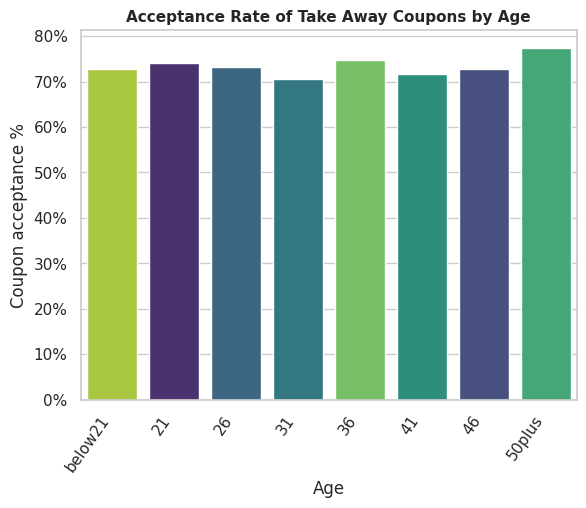

In [117]:
ax = sns.barplot(
    data=take_away,
    x='age',
    y='Y',
    hue='age',
    palette='viridis',
    estimator="mean", # Calculates the average of Y (which is the acceptance rate)
    order=['below21','21','26','31','36','41','46','50plus'],
    errorbar=None
)
plt.xticks(rotation=55, ha='right')
plt.xlabel('Age')
plt.ylabel('Coupon acceptance %')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('Acceptance Rate of Take Away Coupons by Age',
          fontsize=11, fontweight='bold')
plt.show()

There is not a standout difference. Let's look at income.

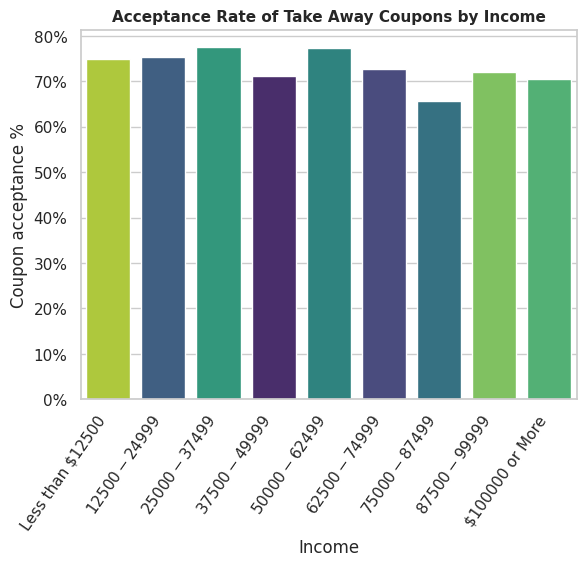

In [118]:
ax = sns.barplot(
    data=take_away,
    x='income',
    y='Y',
    hue='income',
    palette='viridis',
    estimator="mean", # Calculates the average of Y (which is the acceptance rate)
    order=['Less than $12500',
           '$12500 - $24999',
           '$25000 - $37499',
           '$37500 - $49999',
           '$50000 - $62499',
           '$62500 - $74999',
           '$75000 - $87499',
           '$87500 - $99999',
           '$100000 or More'],
    errorbar=None
)
plt.xticks(rotation=55, ha='right')
plt.xlabel('Income')
plt.ylabel('Coupon acceptance %')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('Acceptance Rate of Take Away Coupons by Income',
          fontsize=11, fontweight='bold')
plt.show()


So far, these take away coupons seem to be pretty universally loved. Let's take a look at the acceptance rate by frequency of take out dining by examining acceptance along with the `CarryAway` column data. The unit of time for this frequency was not given, so we will assume it is monthly for now.

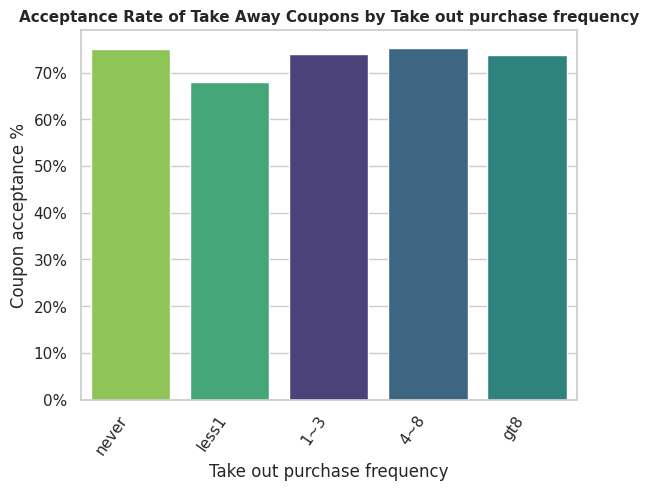

In [119]:
ax = sns.barplot(
    data=take_away,
    x='CarryAway',
    y='Y',
    hue='CarryAway',
    palette='viridis',
    estimator="mean", # Calculates the average of Y (which is the acceptance rate)
    order=['never', 'less1', '1~3', '4~8',  'gt8'],
    errorbar=None
)
plt.xticks(rotation=55, ha='right')
plt.xlabel('Take out purchase frequency')
plt.ylabel('Coupon acceptance %')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('Acceptance Rate of Take Away Coupons by Take out purchase frequency',
          fontsize=11, fontweight='bold')
plt.show()

Still no significant difference between groups. Let's take a look at the acceptance rate based on whether or not the restaurant is in the same, or opposite direction as the driver's heading. (Note that upon inspection of the data, the values in the columns `direction_same` and `direction_opp` were never both `1` or `0` together -- they always had different values, hence the following queries used.)

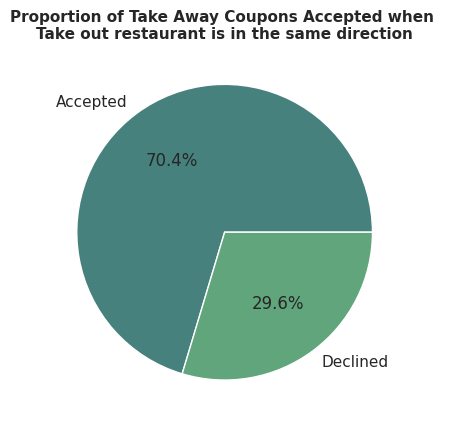

In [120]:
take_away_same_dir = take_away.query('direction_same == 1')

(
  take_away_same_dir['Y'].value_counts()
    .rename(index={0:'Declined', 1:'Accepted'})
    .plot.pie(autopct='%1.1f%%', ylabel='', colors=['#47817e', '#60a57c'])
)
plt.title('Proportion of Take Away Coupons Accepted when \n'
          'Take out restaurant is in the same direction',
          fontsize=11, fontweight='bold')
plt.show()

And now for the case where the take out restaurant is in the opposite direction.

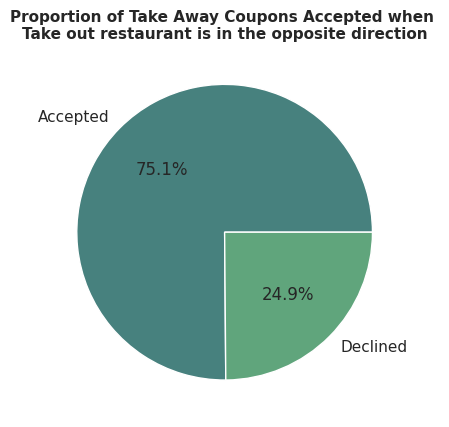

In [121]:
take_away_opp_dir = take_away.query('direction_opp == 1')

(
  take_away_opp_dir['Y'].value_counts()
    .rename(index={0:'Declined', 1:'Accepted'})
    .plot.pie(autopct='%1.1f%%', ylabel='', colors=['#47817e', '#60a57c'])
)
plt.title('Proportion of Take Away Coupons Accepted when \n'
          'Take out restaurant is in the opposite direction',
          fontsize=11, fontweight='bold')
plt.show()

Interestingly, the acceptance rate is slightly higher.

Based on the above, there seems to be a pretty consistent acceptance rate for take out coupons. Based on this quick investigation, businesses offering such coupons need not overthink the targeting criteria as neither age, income, nor take out purchase frequency seem to heavily influence the acceptance rate for these coupons.